# 04 — 線形Kalman状態推定

## 背景・目的
浮動baseのworld位置には直接encoderがない。IMU加速度を積分しつつ、接地足がworldに
固定されるという観測でdriftを抑える。姿勢と関節までKFが推定する、という誤解を解く。

実装対応:
- [`LinearKalmanFilter.cpp`](https://github.com/qiayuanliao/legged_control/tree/a7f381c0367e98e31c01336e678eef47e304d40d/legged_estimation/src/LinearKalmanFilter.cpp)
- [`StateEstimateBase.cpp`](https://github.com/qiayuanliao/legged_control/tree/a7f381c0367e98e31c01336e678eef47e304d40d/legged_estimation/src/StateEstimateBase.cpp)


## 検証範囲に関する必須注記

このprojectでは **ROS2 portを作成・compile・実行していない**。したがってROS2 parityは
**NOT VERIFIED / FAIL-CLOSED** である。上流commit `a7f381c0367e98e31c01336e678eef47e304d40d` はROS1実装であり、
project所有MuJoCo adapterはOCS2のhorizon SQPを瞬時force plannerへ、
Pinocchio/qpOASES WBCをMuJoCo acceleration inverse dynamicsへ置換し、
元のestimator/hardware経路も持たない。保存済み30 scenario dataが示すのはadapter挙動だけで、
上流 `legged_control` の性能でもROS2移行の検証でもない。


In [1]:
# 背景: 浮動base並進は直接計測できず推定が必要になる。目的: Kalman filterの予測・更新を小さい系で確認するため、`from pathlib import Path` の依存を明示して再現可能な実行環境を作る。
from pathlib import Path
# 背景: 浮動base並進は直接計測できず推定が必要になる。目的: Kalman filterの予測・更新を小さい系で確認するため、`import numpy as np` の依存を明示して再現可能な実行環境を作る。
import numpy as np
# 背景: 浮動base並進は直接計測できず推定が必要になる。目的: Kalman filterの予測・更新を小さい系で確認するため、`import matplotlib.pyplot as plt` の依存を明示して再現可能な実行環境を作る。
import matplotlib.pyplot as plt

# 背景: 浮動base並進は直接計測できず推定が必要になる。目的: Kalman filterの予測・更新を小さい系で確認するため、`ROOT` を後続計算で使う明示的な中間量として設定する。 数式: `ROOT = Path.cwd()` の演算・変換をPythonで評価する。
ROOT = Path.cwd()
# 背景: 浮動base並進は直接計測できず推定が必要になる。目的: Kalman filterの予測・更新を小さい系で確認するため、`for candidate in [ROOT, *ROOT.parents]:` の反復範囲を固定して各sampleを処理する。 数式: `for candidate in [ROOT, *ROOT.parents]:` の演算・変換をPythonで評価する。
for candidate in [ROOT, *ROOT.parents]:
    # 背景: 浮動base並進は直接計測できず推定が必要になる。目的: Kalman filterの予測・更新を小さい系で確認するため、`if (candidate / "pyproject.toml").exists():` の条件で安全側の実行分岐を選ぶ。 数式: `if (candidate / "pyproject.toml").exists():` の演算・変換をPythonで評価する。
    if (candidate / "pyproject.toml").exists():
        # 背景: 浮動base並進は直接計測できず推定が必要になる。目的: Kalman filterの予測・更新を小さい系で確認するため、`ROOT` を後続計算で使う明示的な中間量として設定する。 数式: `ROOT = candidate` の演算・変換をPythonで評価する。
        ROOT = candidate
        # 背景: 浮動base並進は直接計測できず推定が必要になる。目的: Kalman filterの予測・更新を小さい系で確認するため、`break` をこの章の処理順に沿って実行する。
        break

# 背景: 浮動base並進は直接計測できず推定が必要になる。目的: Kalman filterの予測・更新を小さい系で確認するため、`np.set_printoptions(precision` を後続計算で使う明示的な中間量として設定する。 数式: `np.set_printoptions(precision=4, suppress=True)` の演算・変換をPythonで評価する。
np.set_printoptions(precision=4, suppress=True)
# 背景: 浮動base並進は直接計測できず推定が必要になる。目的: Kalman filterの予測・更新を小さい系で確認するため、直前の式・構造へ `plt.rcParams.update({"figure.figsize": (9, 4), "axes.grid": True})` の要素または終端を対応付ける。
plt.rcParams.update({"figure.figsize": (9, 4), "axes.grid": True})
# 背景: 浮動base並進は直接計測できず推定が必要になる。目的: Kalman filterの予測・更新を小さい系で確認するため、`print("repository:", ROOT)` の観測値を表示して判定根拠を残す。
print("repository:", ROOT)


repository: /home/takuya/work/mpc_dog


実装のKF状態は
\[
\hat x=[p_b(3),v_b(3),p_{f,1}(3),\ldots,p_{f,4}(3)]\in\mathbb R^{18}.
\]
姿勢はIMU quaternion、関節角/速度はencoderを使う。KF対象はbase並進と足world位置。

予測:
\[
p^+=p+\Delta t\,v+\tfrac12\Delta t^2 a_W,\quad v^+=v+\Delta t a_W.
\]
接地足では \(p_b-p_f\) とbase速度を強く観測し、遊脚では足process noiseを100倍して
world固定という仮定を弱める。


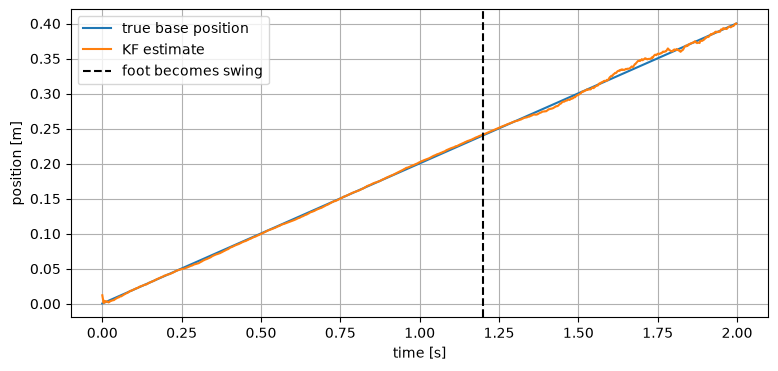

In [2]:
# 教育用1次元KF: [base位置, base速度, 足位置]。
# 実装はこれを3軸・4足へ拡張した18状態である。
# 背景: 浮動base並進は直接計測できず推定が必要になる。目的: Kalman filterの予測・更新を小さい系で確認するため、`dt` を後続計算で使う明示的な中間量として設定する。 数式: `dt = 1/500` の演算・変換をPythonで評価する。
dt = 1/500
# 背景: 浮動base並進は直接計測できず推定が必要になる。目的: Kalman filterの予測・更新を小さい系で確認するため、`A` を後続計算で使う明示的な中間量として設定する。 数式: `A = np.array([[1, dt, 0], [0, 1, 0], [0, 0, 1]], float)` の演算・変換をPythonで評価する。
A = np.array([[1, dt, 0], [0, 1, 0], [0, 0, 1]], float)
# 背景: 浮動base並進は直接計測できず推定が必要になる。目的: Kalman filterの予測・更新を小さい系で確認するため、`B` を後続計算で使う明示的な中間量として設定する。 数式: `B = np.array([0.5*dt**2, dt, 0.0])` の演算・変換をPythonで評価する。
B = np.array([0.5*dt**2, dt, 0.0])
# 相対位置 base-foot と base速度を観測
# 背景: 浮動base並進は直接計測できず推定が必要になる。目的: Kalman filterの予測・更新を小さい系で確認するため、`C` を後続計算で使う明示的な中間量として設定する。 数式: `C = np.array([[1, 0, -1], [0, 1, 0]], float)` の演算・変換をPythonで評価する。
C = np.array([[1, 0, -1], [0, 1, 0]], float)

# 背景: 浮動base並進は直接計測できず推定が必要になる。目的: Kalman filterの予測・更新を小さい系で確認するため、`xhat` を後続計算で使う明示的な中間量として設定する。 数式: `xhat = np.array([0.0, 0.0, 0.0])` の演算・変換をPythonで評価する。
xhat = np.array([0.0, 0.0, 0.0])
# 背景: 浮動base並進は直接計測できず推定が必要になる。目的: Kalman filterの予測・更新を小さい系で確認するため、`P` を後続計算で使う明示的な中間量として設定する。 数式: `P = np.eye(3) * 0.1` の演算・変換をPythonで評価する。
P = np.eye(3) * 0.1
# 背景: 浮動base並進は直接計測できず推定が必要になる。目的: Kalman filterの予測・更新を小さい系で確認するため、`rng` を後続計算で使う明示的な中間量として設定する。 数式: `rng = np.random.default_rng(4)` の演算・変換をPythonで評価する。
rng = np.random.default_rng(4)
# 背景: 浮動base並進は直接計測できず推定が必要になる。目的: Kalman filterの予測・更新を小さい系で確認するため、`history` を後続計算で使う明示的な中間量として設定する。 数式: `history = []` の演算・変換をPythonで評価する。
history = []
# 背景: 浮動base並進は直接計測できず推定が必要になる。目的: Kalman filterの予測・更新を小さい系で確認するため、`true_x` を後続計算で使う明示的な中間量として設定する。 数式: `true_x = np.array([0.0, 0.2, 0.0])` の演算・変換をPythonで評価する。
true_x = np.array([0.0, 0.2, 0.0])

# 背景: 浮動base並進は直接計測できず推定が必要になる。目的: Kalman filterの予測・更新を小さい系で確認するため、`for k in range(1000):` の反復範囲を固定して各sampleを処理する。
for k in range(1000):
    # 背景: 浮動base並進は直接計測できず推定が必要になる。目的: Kalman filterの予測・更新を小さい系で確認するため、`true_x[0] +` を後続計算で使う明示的な中間量として設定する。 数式: `true_x[0] += dt * true_x[1]` の演算・変換をPythonで評価する。
    true_x[0] += dt * true_x[1]
    # 背景: 浮動base並進は直接計測できず推定が必要になる。目的: Kalman filterの予測・更新を小さい系で確認するため、`a_meas` を後続計算で使う明示的な中間量として設定する。 数式: `a_meas = rng.normal(0, 0.15)` の演算・変換をPythonで評価する。
    a_meas = rng.normal(0, 0.15)
    # 背景: 浮動base並進は直接計測できず推定が必要になる。目的: Kalman filterの予測・更新を小さい系で確認するため、`contact` を後続計算で使う明示的な中間量として設定する。 数式: `contact = k < 600` の演算・変換をPythonで評価する。
    contact = k < 600
    # 背景: 浮動base並進は直接計測できず推定が必要になる。目的: Kalman filterの予測・更新を小さい系で確認するため、`Q` を後続計算で使う明示的な中間量として設定する。 数式: `Q = np.diag([1e-8, 2e-5, 1e-7 if contact else 1e-2])` の演算・変換をPythonで評価する。
    Q = np.diag([1e-8, 2e-5, 1e-7 if contact else 1e-2])
    # 背景: 浮動base並進は直接計測できず推定が必要になる。目的: Kalman filterの予測・更新を小さい系で確認するため、`R` を後続計算で使う明示的な中間量として設定する。 数式: `R = np.diag([2e-4 if contact else 2e-1, 5e-3 if contact else 2e-1])` の演算・変換をPythonで評価する。
    R = np.diag([2e-4 if contact else 2e-1, 5e-3 if contact else 2e-1])
    # 背景: 浮動base並進は直接計測できず推定が必要になる。目的: Kalman filterの予測・更新を小さい系で確認するため、`xhat` を後続計算で使う明示的な中間量として設定する。 数式: `xhat = A @ xhat + B * a_meas` の演算・変換をPythonで評価する。
    xhat = A @ xhat + B * a_meas
    # 背景: 浮動base並進は直接計測できず推定が必要になる。目的: Kalman filterの予測・更新を小さい系で確認するため、`P` を後続計算で使う明示的な中間量として設定する。 数式: `P = A @ P @ A.T + Q` の演算・変換をPythonで評価する。
    P = A @ P @ A.T + Q
    # 背景: 浮動base並進は直接計測できず推定が必要になる。目的: Kalman filterの予測・更新を小さい系で確認するため、`y` を後続計算で使う明示的な中間量として設定する。 数式: `y = C @ true_x + rng.multivariate_normal(np.zeros(2), R)` の演算・変換をPythonで評価する。
    y = C @ true_x + rng.multivariate_normal(np.zeros(2), R)
    # 背景: 浮動base並進は直接計測できず推定が必要になる。目的: Kalman filterの予測・更新を小さい系で確認するため、`S` を後続計算で使う明示的な中間量として設定する。 数式: `S = C @ P @ C.T + R` の演算・変換をPythonで評価する。
    S = C @ P @ C.T + R
    # 背景: 浮動base並進は直接計測できず推定が必要になる。目的: Kalman filterの予測・更新を小さい系で確認するため、`K` を後続計算で使う明示的な中間量として設定する。 数式: `K = np.linalg.solve(S, C @ P).T` の演算・変換をPythonで評価する。
    K = np.linalg.solve(S, C @ P).T
    # 背景: 浮動base並進は直接計測できず推定が必要になる。目的: Kalman filterの予測・更新を小さい系で確認するため、`xhat +` を後続計算で使う明示的な中間量として設定する。 数式: `xhat += K @ (y - C @ xhat)` の演算・変換をPythonで評価する。
    xhat += K @ (y - C @ xhat)
    # 背景: 浮動base並進は直接計測できず推定が必要になる。目的: Kalman filterの予測・更新を小さい系で確認するため、`P` を後続計算で使う明示的な中間量として設定する。 数式: `P = (np.eye(3) - K @ C) @ P` の演算・変換をPythonで評価する。
    P = (np.eye(3) - K @ C) @ P
    # 背景: 浮動base並進は直接計測できず推定が必要になる。目的: Kalman filterの予測・更新を小さい系で確認するため、直前の式・構造へ `history.append([k*dt, true_x[0], xhat[0], contact])` の要素または終端を対応付ける。 数式: `history.append([k*dt, true_x[0], xhat[0], contact])` の演算・変換をPythonで評価する。
    history.append([k*dt, true_x[0], xhat[0], contact])

# 背景: 浮動base並進は直接計測できず推定が必要になる。目的: Kalman filterの予測・更新を小さい系で確認するため、`h` を後続計算で使う明示的な中間量として設定する。 数式: `h = np.asarray(history)` の演算・変換をPythonで評価する。
h = np.asarray(history)
# 背景: 浮動base並進は直接計測できず推定が必要になる。目的: Kalman filterの予測・更新を小さい系で確認するため、`plt.plot(h[:,0], h[:,1], label` を後続計算で使う明示的な中間量として設定する。 数式: `plt.plot(h[:,0], h[:,1], label="true base position")` の演算・変換をPythonで評価する。
plt.plot(h[:,0], h[:,1], label="true base position")
# 背景: 浮動base並進は直接計測できず推定が必要になる。目的: Kalman filterの予測・更新を小さい系で確認するため、`plt.plot(h[:,0], h[:,2], label` を後続計算で使う明示的な中間量として設定する。 数式: `plt.plot(h[:,0], h[:,2], label="KF estimate")` の演算・変換をPythonで評価する。
plt.plot(h[:,0], h[:,2], label="KF estimate")
# 背景: 浮動base並進は直接計測できず推定が必要になる。目的: Kalman filterの予測・更新を小さい系で確認するため、`plt.axvline(600*dt, color` を後続計算で使う明示的な中間量として設定する。 数式: `plt.axvline(600*dt, color="k", ls="--", label="foot becomes swing")` の演算・変換をPythonで評価する。
plt.axvline(600*dt, color="k", ls="--", label="foot becomes swing")
# 背景: 浮動base並進は直接計測できず推定が必要になる。目的: Kalman filterの予測・更新を小さい系で確認するため、直前の式・構造へ `plt.xlabel("time [s]"); plt.ylabel("position [m]"); plt.legend(); plt.sh…` の要素または終端を対応付ける。
plt.xlabel("time [s]"); plt.ylabel("position [m]"); plt.legend(); plt.show()


## 読み方と限界
- IMU値はworldへ回して重力 `[0,0,-9.81]` を加える。符号ミスは静止時加速度で検査する。
- 接地はA1実機で `footForce > 40` のbool。確率的接触ではない。
- visual odometry topicが来た場合だけ位置を上書きする枝がある。
- `CheaterController` はground truthを使うsim専用で、実機性能の証拠にはならない。

### チューニング順
センサ静止bias → frame/重力 → 接触判定 → measurement noise → process noise。
noiseを先に触り、frame誤りを「滑らかに隠す」のは避ける。


## 章固有の背景
                free-floating base位置はencoderで直接測れず、IMU積分だけではbiasがdriftになる。

                ## 章固有の目的
                接地足の相対運動学を観測に使う18状態linear KFを予測・観測・noise切替の順で読む。

                ## この章のASCIIデータフロー
                ```text
                IMU q,a -> rotate+gravity -> KF predict [p,v,pf]
q,dq -> Pinocchio foot kinematics -> relative observation -> KF update
contact ---------------------------> Q/R scaling
                ```

                ## 上流C++ / faithful pseudocode と数式の行対応
                ```cpp
                // external/legged_control/legged_estimation/src/LinearKalmanFilter.cpp
a_.block<3,3>(0,3)=dt*I;       // p^+=p+dt*v
b_.block<3,3>(0,0)=dt^2/2*I;  // +0.5*dt^2*a_W
b_.block<3,3>(3,0)=dt*I;      // v^+=v+dt*a_W
xhat_=a_*xhat_+b_*accel;      // x^- = A x + B a
S=C_*P_*C_.transpose()+R;      // innovation covariance
xhat_ += K*(y-C_*xhat_);      // x^+ = x^- + K residual
// swing foot: process/measurement noiseを大きくしp_f^W固定仮定を弱める
                ```

                **事実のラベル**: `external/legged_control/` の記述はcommit
                `a7f381c0367e98e31c01336e678eef47e304d40d` の上流実装事実。数式展開はそのinterfaceを説明する理論。
                `src/legged_control_mujoco/` に言及した行はproject所有adapterの実装であり、
                ROS1/OCS2 SQP原実装とは同一ではない。

                ## 章固有の結論
                KFが推定するのはbase並進と4足world位置である。姿勢はIMU、関節状態はencoder由来で、遊脚ではworld固定仮定をnoiseで弱める。
